# Module 3: ML Models

**Muc tieu:** Train 3 mo hinh ML:
- **3.1** K-Means Clustering — phan cum phim
- **3.2** Naive Bayes — phan loai the loai tu poster
- **3.3** Association Rules (Apriori) — luat ket hop the loai

**Input:**
- `models/combined_features.npy`
- `models/cnn_features.npy`
- `models/movie_ids.npy`
- `data/processed/movies_valid.csv`

**Output:**
- `models/kmeans.pkl`, `models/cluster_labels.npy`
- `models/nb_model.pkl`, `models/mlb_encoder.pkl`
- `models/rules.csv`
- `data/processed/movies_valid.csv` (cap nhat them cot cluster_id, pca_x, pca_y)

In [1]:
# !pip install scikit-learn mlxtend joblib numpy pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import os

# Load du lieu dau vao
combined = np.load("../models/combined_features.npy")
cnn      = np.load("../models/cnn_features.npy")
movie_ids = np.load("../models/movie_ids.npy")
df = pd.read_csv("../data/processed/movies_valid.csv")

print(f"combined_features: {combined.shape}")
print(f"cnn_features:      {cnn.shape}")
print(f"movie_ids:         {movie_ids.shape}")
print(f"df (movies_valid): {df.shape}")

assert combined.shape[0] == cnn.shape[0] == len(movie_ids) == len(df), \
    "So luong phim khong khop giua cac file!"
print("Kiem tra so luong: PASS")

combined_features: (4752, 2548)
cnn_features:      (4752, 2048)
movie_ids:         (4752,)
df (movies_valid): (4752, 9)
Kiem tra so luong: PASS


---
## 3.1 K-Means Clustering

### 3.1.1 Elbow Curve — chon K toi uu

Dang tinh Elbow Curve...
  K= 5 | Inertia: 99982
  K=10 | Inertia: 97038
  K=15 | Inertia: 95323
  K=20 | Inertia: 94182
  K=25 | Inertia: 93460
  K=30 | Inertia: 93475
  K=35 | Inertia: 92667
  K=40 | Inertia: 92183


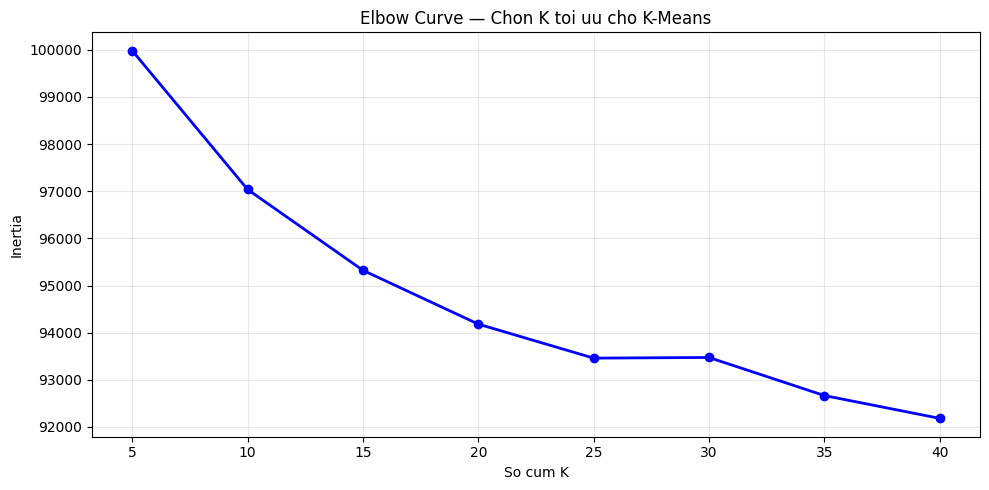

Da luu elbow_curve.png


In [3]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Dung MiniBatchKMeans de tinh nhanh Elbow Curve
K_range = range(5, 41, 5)
inertias = []

print("Dang tinh Elbow Curve...")
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
    km.fit(combined)
    inertias.append(km.inertia_)
    print(f"  K={k:2d} | Inertia: {km.inertia_:.0f}")

# Ve Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2)
plt.xlabel('So cum K')
plt.ylabel('Inertia')
plt.title('Elbow Curve — Chon K toi uu cho K-Means')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../models/elbow_curve.png", dpi=100)
plt.show()
print("Da luu elbow_curve.png")

In [4]:
# Chon K dua tren Elbow Curve o tren
# Mac dinh K=20 theo plan, dieu chinh neu can
K_OPTIMAL = 20
print(f"K toi uu duoc chon: {K_OPTIMAL}")
print("(Xem bieu do Elbow Curve o tren de dieu chinh neu can)")

K toi uu duoc chon: 20
(Xem bieu do Elbow Curve o tren de dieu chinh neu can)


### 3.1.2 Train KMeans voi K toi uu

In [5]:
print(f"Dang train KMeans(k={K_OPTIMAL})...")
kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10,
    max_iter=300
)
cluster_labels = kmeans.fit_predict(combined)

print(f"Train xong!")
print(f"Inertia: {kmeans.inertia_:.0f}")

# Thong ke so phim moi cum
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"\nSo phim moi cum:")
for cid, cnt in zip(unique, counts):
    print(f"  Cum {cid:2d}: {cnt} phim")

Dang train KMeans(k=20)...
Train xong!
Inertia: 93306

So phim moi cum:
  Cum  0: 167 phim
  Cum  1: 148 phim
  Cum  2: 228 phim
  Cum  3: 170 phim
  Cum  4: 191 phim
  Cum  5: 217 phim
  Cum  6: 424 phim
  Cum  7: 274 phim
  Cum  8: 224 phim
  Cum  9: 195 phim
  Cum 10: 284 phim
  Cum 11: 209 phim
  Cum 12: 182 phim
  Cum 13: 267 phim
  Cum 14: 348 phim
  Cum 15: 346 phim
  Cum 16: 251 phim
  Cum 17: 170 phim
  Cum 18: 167 phim
  Cum 19: 290 phim


### 3.1.3 Danh gia Silhouette Score & Davies-Bouldin Index

In [6]:
# Dung subset 2000 mau de tinh nhanh (silhouette toan bo rat cham)
sample_size = min(2000, len(combined))
np.random.seed(42)
sample_idx = np.random.choice(len(combined), sample_size, replace=False)

sil_score = silhouette_score(combined[sample_idx], cluster_labels[sample_idx])
db_score  = davies_bouldin_score(combined[sample_idx], cluster_labels[sample_idx])

print(f"Silhouette Score:      {sil_score:.4f}  (tot >= 0.3, cang cao cang tot)")
print(f"Davies-Bouldin Index:  {db_score:.4f}  (cang thap cang tot)")

if sil_score >= 0.3:
    print("Silhouette >= 0.3: PASS")
else:
    print(f"Silhouette < 0.3: co the thu dieu chinh K")

Silhouette Score:      -0.0026  (tot >= 0.3, cang cao cang tot)
Davies-Bouldin Index:  5.0454  (cang thap cang tot)
Silhouette < 0.3: co the thu dieu chinh K


### 3.1.4 Precompute PCA 2D

Dang tinh PCA 2D...
PCA explained variance: 6.6%


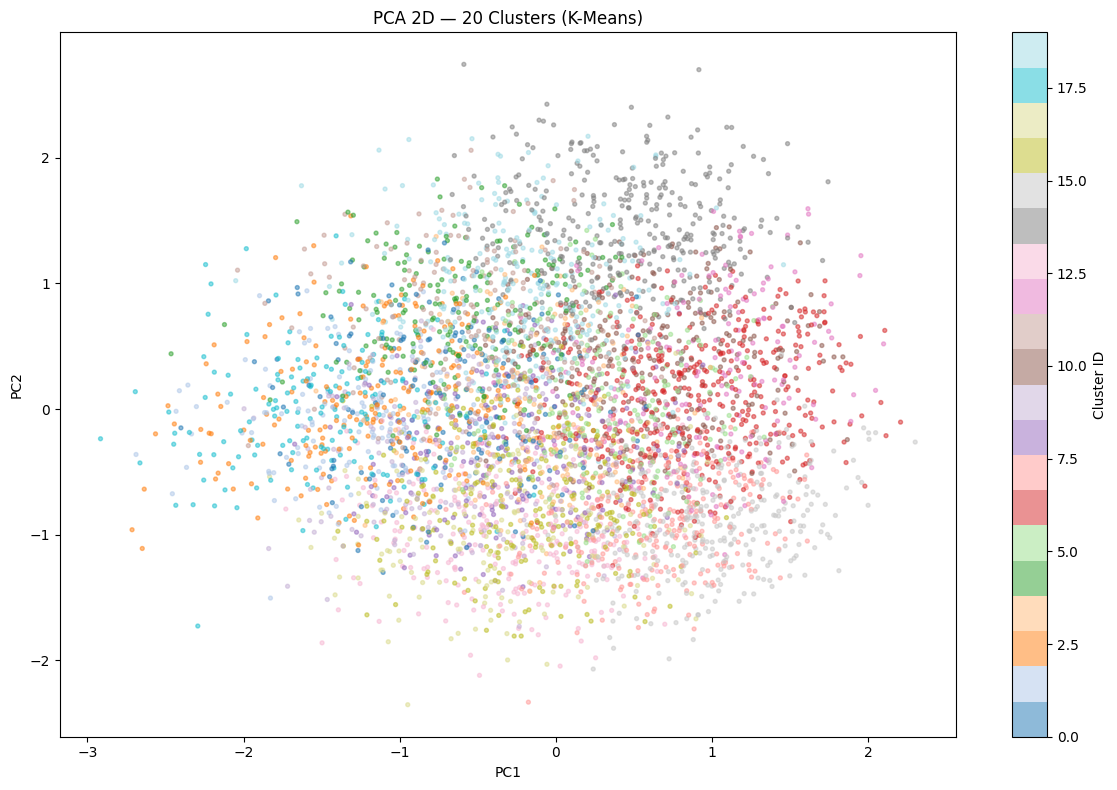

Da luu pca_clusters.png


In [7]:
from sklearn.decomposition import PCA

print("Dang tinh PCA 2D...")
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(combined)

pca_x = pca_coords[:, 0]
pca_y = pca_coords[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_x, pca_y, c=cluster_labels, cmap='tab20', alpha=0.5, s=8)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PCA 2D — {K_OPTIMAL} Clusters (K-Means)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig("../models/pca_clusters.png", dpi=100)
plt.show()
print("Da luu pca_clusters.png")

### 3.1.5 & 3.1.6 Luu cluster_id, pca_x, pca_y vao CSV + luu model

In [8]:
# Cap nhat df voi cluster_id, pca_x, pca_y
df['cluster_id'] = cluster_labels
df['pca_x'] = pca_x
df['pca_y'] = pca_y

# Luu lai movies_valid.csv
df.to_csv("../data/processed/movies_valid.csv", index=False)
print(f"Da cap nhat movies_valid.csv voi cluster_id, pca_x, pca_y")

# Luu model va labels
joblib.dump(kmeans, "../models/kmeans.pkl")
np.save("../models/cluster_labels.npy", cluster_labels)
print("Da luu kmeans.pkl va cluster_labels.npy")

Da cap nhat movies_valid.csv voi cluster_id, pca_x, pca_y
Da luu kmeans.pkl va cluster_labels.npy


---
## 3.2 Naive Bayes — Multi-label Genre Classification

### 3.2.1 & 3.2.2 Tao multi-label binary matrix, loc the loai >= 100 phim

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

# Parse genres
genres_lists = df['genres'].apply(json.loads).tolist()

# Dem so phim moi the loai
all_genres_flat = [g for gl in genres_lists for g in gl]
genre_counts = Counter(all_genres_flat)

print("So phim moi the loai:")
for genre, count in sorted(genre_counts.items(), key=lambda x: -x[1]):
    flag = "OK" if count >= 100 else "< 100, bo qua"
    print(f"  {genre:<25} {count:4d}  {flag}")

# Giu lai the loai co >= 100 phim
valid_genres = [g for g, c in genre_counts.items() if c >= 100]
print(f"\nSo the loai hop le (>= 100 phim): {len(valid_genres)}")
print(f"Cac the loai: {sorted(valid_genres)}")

So phim moi the loai:
  Drama                     2286  OK
  Comedy                    1717  OK
  Thriller                  1272  OK
  Action                    1152  OK
  Romance                    892  OK
  Adventure                  789  OK
  Crime                      694  OK
  Science Fiction            532  OK
  Horror                     518  OK
  Family                     513  OK
  Fantasy                    423  OK
  Mystery                    347  OK
  Animation                  233  OK
  History                    197  OK
  Music                      183  OK
  War                        144  OK
  Documentary                104  OK
  Western                     82  < 100, bo qua
  Foreign                     34  < 100, bo qua
  TV Movie                     7  < 100, bo qua

So the loai hop le (>= 100 phim): 17
Cac the loai: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 

In [10]:
# Loc genres_lists chi giu the loai hop le
genres_filtered = [[g for g in gl if g in valid_genres] for gl in genres_lists]

# MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=sorted(valid_genres))
Y = mlb.fit_transform(genres_filtered)

print(f"Label matrix shape: {Y.shape}")  # (N, n_genres)
print(f"Classes: {mlb.classes_.tolist()}")

Label matrix shape: (4752, 17)
Classes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']


### 3.2.3 Train/Test Split 80/20

In [11]:
from sklearn.model_selection import train_test_split

# Dung CNN features lam input cho Naive Bayes
X_train, X_test, Y_train, Y_test = train_test_split(
    cnn, Y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Y_train: {Y_train.shape}")
print(f"Y_test:  {Y_test.shape}")

X_train: (3801, 2048)
X_test:  (951, 2048)
Y_train: (3801, 17)
Y_test:  (951, 17)


### 3.2.4 Train MultiOutputClassifier(GaussianNB)

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier

print("Dang train Naive Bayes...")
nb_model = MultiOutputClassifier(GaussianNB(), n_jobs=-1)
nb_model.fit(X_train, Y_train)
print("Train xong!")

Dang train Naive Bayes...
Train xong!


### 3.2.5 Danh gia: Hamming Loss, F1, Precision, Recall

In [13]:
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    classification_report
)

Y_pred = nb_model.predict(X_test)

hl    = hamming_loss(Y_test, Y_pred)
f1_mi = f1_score(Y_test, Y_pred, average='micro', zero_division=0)
f1_ma = f1_score(Y_test, Y_pred, average='macro', zero_division=0)
prec  = precision_score(Y_test, Y_pred, average='micro', zero_division=0)
rec   = recall_score(Y_test, Y_pred, average='micro', zero_division=0)

print("=" * 50)
print("KET QUA DANH GIA NAIVE BAYES")
print("=" * 50)
print(f"Hamming Loss:      {hl:.4f}  (cang thap cang tot)")
print(f"F1 (micro):        {f1_mi:.4f}")
print(f"F1 (macro):        {f1_ma:.4f}")
print(f"Precision (micro): {prec:.4f}")
print(f"Recall (micro):    {rec:.4f}")

# Exact match accuracy (phai du het cac nhan)
exact_match = np.mean(np.all(Y_pred == Y_test, axis=1))
print(f"Exact Match Acc:   {exact_match:.4f}")

# Per-label accuracy
per_label_acc = np.mean(Y_pred == Y_test, axis=0)
print(f"\nPer-label accuracy:")
for label, acc in zip(mlb.classes_, per_label_acc):
    print(f"  {label:<25} {acc:.3f}")

KET QUA DANH GIA NAIVE BAYES
Hamming Loss:      0.2462  (cang thap cang tot)
F1 (micro):        0.4612
F1 (macro):        0.3873
Precision (micro): 0.3461
Recall (micro):    0.6910
Exact Match Acc:   0.0126

Per-label accuracy:
  Action                    0.758
  Adventure                 0.712
  Animation                 0.905
  Comedy                    0.746
  Crime                     0.650
  Documentary               0.893
  Drama                     0.637
  Family                    0.821
  Fantasy                   0.738
  History                   0.714
  Horror                    0.790
  Music                     0.739
  Mystery                   0.757
  Romance                   0.668
  Science Fiction           0.773
  Thriller                  0.719
  War                       0.794


### 3.2.6 Luu nb_model.pkl & mlb_encoder.pkl

In [14]:
joblib.dump(nb_model, "../models/nb_model.pkl")
joblib.dump(mlb, "../models/mlb_encoder.pkl")
print("Da luu nb_model.pkl va mlb_encoder.pkl")

# Test nhanh
nb_loaded = joblib.load("../models/nb_model.pkl")
mlb_loaded = joblib.load("../models/mlb_encoder.pkl")
pred_test = nb_loaded.predict(cnn[:5])
genres_pred = mlb_loaded.inverse_transform(pred_test)
print(f"\nTest prediction cho 5 phim dau:")
for i, (gp, title) in enumerate(zip(genres_pred, df['title'].head(5))):
    gt = json.loads(df.iloc[i]['genres'])
    print(f"  {title[:30]:<30} | Du doan: {list(gp)} | Thuc te: {gt}")

Da luu nb_model.pkl va mlb_encoder.pkl

Test prediction cho 5 phim dau:
  Avatar                         | Du doan: ['Drama', 'Fantasy', 'History', 'Horror', 'Mystery', 'Science Fiction', 'Thriller', 'War'] | Thuc te: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
  Pirates of the Caribbean: At W | Du doan: ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction'] | Thuc te: ['Adventure', 'Fantasy', 'Action']
  Spectre                        | Du doan: ['Comedy', 'Crime', 'Music'] | Thuc te: ['Action', 'Adventure', 'Crime']
  The Dark Knight Rises          | Du doan: ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction', 'Thriller', 'War'] | Thuc te: ['Action', 'Crime', 'Drama', 'Thriller']
  John Carter                    | Du doan: ['Action', 'Adventure', 'Family', 'Fantasy', 'Science Fiction'] | Thuc te: ['Action', 'Adventure', 'Science Fiction']


---
## 3.3 Association Rules (Apriori)

### 3.3.1 Tao transaction matrix

In [15]:
# Dung tat ca the loai (khong gioi han >= 100)
all_genre_names = sorted(set(all_genres_flat))

# Tao transaction matrix (0/1)
mlb_apriori = MultiLabelBinarizer(classes=all_genre_names)
transaction_matrix = mlb_apriori.fit_transform(genres_lists)
df_transactions = pd.DataFrame(transaction_matrix, columns=all_genre_names, dtype=bool)

print(f"Transaction matrix shape: {df_transactions.shape}")
print(f"So the loai: {len(all_genre_names)}")
print(f"Cac the loai: {all_genre_names}")

Transaction matrix shape: (4752, 20)
So the loai: 20
Cac the loai: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


### 3.3.2 Apriori

In [16]:
from mlxtend.frequent_patterns import apriori, association_rules

print("Dang chay Apriori (min_support=0.05)...")
frequent_itemsets = apriori(
    df_transactions,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)

print(f"So frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Dang chay Apriori (min_support=0.05)...
So frequent itemsets: 27
     support                      itemsets
4   0.481061            frozenset({Drama})
2   0.361322           frozenset({Comedy})
11  0.267677         frozenset({Thriller})
0   0.242424           frozenset({Action})
9   0.187710          frozenset({Romance})
1   0.166035        frozenset({Adventure})
3   0.146044            frozenset({Crime})
23  0.126473   frozenset({Romance, Drama})
18  0.120791    frozenset({Drama, Comedy})
24  0.116582  frozenset({Thriller, Drama})


### 3.3.3 & 3.3.4 Sinh luat ket hop, loc lift > 1.0

In [17]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

# Chi giu luat co lift > 1.0 (co y nghia thong ke)
rules = rules[rules['lift'] > 1.0].copy()

# Sap xep theo confidence giam dan
rules = rules.sort_values(['confidence', 'lift'], ascending=False).reset_index(drop=True)

print(f"So luat ket hop (lift > 1.0): {len(rules)}")
print(f"\nTop 15 luat ket hop:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string())

assert len(rules) >= 10, f"Chi co {len(rules)} luat, can >= 10. Thu giam min_support."

So luat ket hop (lift > 1.0): 12

Top 15 luat ket hop:
                     antecedents             consequents   support  confidence      lift
0           frozenset({Mystery})   frozenset({Thriller})  0.050715    0.694524  2.594639
1           frozenset({Romance})      frozenset({Drama})  0.126473    0.673767  1.400586
2             frozenset({Crime})   frozenset({Thriller})  0.087121    0.596542  2.228590
3         frozenset({Adventure})     frozenset({Action})  0.097643    0.588086  2.425856
4            frozenset({Family})     frozenset({Comedy})  0.062921    0.582846  1.613095
5            frozenset({Horror})   frozenset({Thriller})  0.061027    0.559846  2.091499
6             frozenset({Crime})      frozenset({Drama})  0.079756    0.546110  1.135220
7           frozenset({Romance})     frozenset({Comedy})  0.101641    0.541480  1.498609
8   frozenset({Science Fiction})     frozenset({Action})  0.057870    0.516917  2.132284
9            frozenset({Action})   frozenset({Thriller}

### 3.3.5 Luu rules.csv

In [18]:
# Chuyen frozenset sang string de luu CSV
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(x)))

rules_export.to_csv("../models/rules.csv", index=False)
print(f"Da luu {len(rules_export)} luat vao models/rules.csv")
print(rules_export.head(5).to_string())

Da luu 12 luat vao models/rules.csv
  antecedents consequents   support  confidence      lift
0     Mystery    Thriller  0.050715    0.694524  2.594639
1     Romance       Drama  0.126473    0.673767  1.400586
2       Crime    Thriller  0.087121    0.596542  2.228590
3   Adventure      Action  0.097643    0.588086  2.425856
4      Family      Comedy  0.062921    0.582846  1.613095


---
## Test Module 3 (Tong hop)

In [19]:
import joblib, numpy as np, pandas as pd
from sklearn.metrics import silhouette_score

combined   = np.load("../models/combined_features.npy")
cnn        = np.load("../models/cnn_features.npy")
labels     = np.load("../models/cluster_labels.npy")
kmeans_m   = joblib.load("../models/kmeans.pkl")
nb_m       = joblib.load("../models/nb_model.pkl")
mlb_m      = joblib.load("../models/mlb_encoder.pkl")
rules_df   = pd.read_csv("../models/rules.csv")

print("=" * 55)
print("TEST MODULE 3")
print("=" * 55)

# --- K-Means ---
sample_idx = np.random.choice(len(combined), min(1000, len(combined)), replace=False)
sil = silhouette_score(combined[sample_idx], labels[sample_idx])
n_clusters = len(set(labels))
print(f"[K-Means] Silhouette Score: {sil:.3f}  {'PASS' if sil >= 0.3 else 'WARN (< 0.3)'}")
print(f"[K-Means] So cum: {n_clusters}")

# --- Naive Bayes ---
pred = nb_m.predict(cnn[:5])
genres_pred = mlb_m.inverse_transform(pred)
print(f"\n[NB] Prediction cho 5 phim dau:")
for gp in genres_pred:
    print(f"  {list(gp)}")

# --- Association Rules ---
print(f"\n[Rules] So luat: {len(rules_df)}  {'PASS' if len(rules_df) >= 10 else 'FAIL'}")
print(rules_df[['antecedents', 'consequents', 'confidence', 'lift']].head(5).to_string())

print("\nModule 3 hoan thanh! San sang cho Module 4.")

TEST MODULE 3
[K-Means] Silhouette Score: -0.006  WARN (< 0.3)
[K-Means] So cum: 20

[NB] Prediction cho 5 phim dau:
  ['Drama', 'Fantasy', 'History', 'Horror', 'Mystery', 'Science Fiction', 'Thriller', 'War']
  ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction']
  ['Comedy', 'Crime', 'Music']
  ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction', 'Thriller', 'War']
  ['Action', 'Adventure', 'Family', 'Fantasy', 'Science Fiction']

[Rules] So luat: 12  PASS
  antecedents consequents  confidence      lift
0     Mystery    Thriller    0.694524  2.594639
1     Romance       Drama    0.673767  1.400586
2       Crime    Thriller    0.596542  2.228590
3   Adventure      Action    0.588086  2.425856
4      Family      Comedy    0.582846  1.613095

Module 3 hoan thanh! San sang cho Module 4.


In [20]:
# Tong ket cac file da tao
print("=" * 55)
print("FILE OUTPUT MODULE 3")
print("=" * 55)
files = [
    "../models/kmeans.pkl",
    "../models/cluster_labels.npy",
    "../models/nb_model.pkl",
    "../models/mlb_encoder.pkl",
    "../models/rules.csv",
    "../models/elbow_curve.png",
    "../models/pca_clusters.png",
    "../data/processed/movies_valid.csv",
]
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  [OK] {f:<45} {size:.1f} KB")
    else:
        print(f"  [MISS] {f}")

FILE OUTPUT MODULE 3
  [OK] ../models/kmeans.pkl                          218.3 KB
  [OK] ../models/cluster_labels.npy                  18.7 KB
  [OK] ../models/nb_model.pkl                        554.8 KB
  [OK] ../models/mlb_encoder.pkl                     0.9 KB
  [OK] ../models/rules.csv                           0.9 KB
  [OK] ../models/elbow_curve.png                     33.7 KB
  [OK] ../models/pca_clusters.png                    369.7 KB
  [OK] ../data/processed/movies_valid.csv            2764.1 KB
